Modern genomics has entered the era of **high-dimensional biology**. Large-scale datasets from genome-wide association studies (GWAS), transcriptomics, proteomics, metabolomics, and imaging genetics contain thousands of variables and traits measured simultaneously.

One major challenge in statistical genetics is understanding:

- Which traits share common genetic architecture?
- Which genetic variants influence multiple diseases?
- How can we identify hidden biological pathways?

To answer these questions, researchers typically use two broad analytical paradigms:

1. **Hypothesis-Free (Exploratory) Analysis**
2. **Hypothesis-Driven (Explanatory) Analysis**

In this tutorial, we will explore both approaches conceptually and practically using Python examples.

---

#### Learning Objectives

By the end of this tutorial, you will understand:

- The difference between exploratory and confirmatory analysis
- When to use hypothesis-free approaches
- When hypothesis-driven models are more appropriate
- Common methods used in statistical genetics
- How clustering and regression methods work
- How to analyze synthetic GWAS-like datasets in Python

---

### Why Does This Matter in Genetics?

:contentReference[oaicite:0]{index=0} is common in complex diseases.

For example:

- One genetic variant may influence:
  - schizophrenia
  - bipolar disorder
  - depression
  - anxiety

This creates highly interconnected biological systems.

Traditional single-trait analysis often fails to capture these relationships.

Modern statistical genetics therefore relies heavily on:

- unsupervised learning
- latent variable models
- covariance analysis
- multivariate statistics

---

### Two Major Paradigms

| Approach | Goal | Assumptions | Examples |
|---|---|---|---|
| Hypothesis-Free | Discover hidden patterns | Minimal assumptions | Clustering, PCA, VAE |
| Hypothesis-Driven | Test predefined relationships | Strong statistical assumptions | Regression, SEM |

---

## Part 1 — Hypothesis-Free Analysis

## What is Hypothesis-Free Analysis?

Hypothesis-free methods are also called:

- exploratory analysis
- data-driven analysis
- unsupervised learning

These methods attempt to identify hidden structure in data **without imposing strong prior assumptions**.

Instead of asking:

> “Does gene X influence trait Y?”

we ask:

> “What hidden structure exists in the data?”

---

## Characteristics of Hypothesis-Free Methods

- Minimal assumptions
- Often unsupervised
- Useful for large-scale datasets
- Can reveal unexpected biological patterns
- Ideal for discovery science

---

## Common Hypothesis-Free Methods

| Method | Purpose |
|---|---|
| K-Means Clustering | Group similar traits |
| Hierarchical Clustering | Build trait similarity trees |
| PCA/SVD | Reduce dimensionality |
| t-SNE/UMAP | Visualization |
| VAE | Learn latent representations |
| NMF | Discover hidden biological modules |

---

#### Example Dataset

We will generate a synthetic GWAS-style dataset.

In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n_samples = 500

trait1 = np.random.normal(0, 1, n_samples)
trait2 = trait1 * 0.8 + np.random.normal(0, 0.3, n_samples)
trait3 = trait1 * -0.5 + np.random.normal(0, 0.5, n_samples)
trait4 = np.random.normal(0, 1, n_samples)
trait5 = trait4 * 0.7 + np.random.normal(0, 0.4, n_samples)

df = pd.DataFrame({
    "Trait_1": trait1,
    "Trait_2": trait2,
    "Trait_3": trait3,
    "Trait_4": trait4,
    "Trait_5": trait5
})

df.head()

,Trait_1,Trait_2,Trait_3,Trait_4,Trait_5
0,0.496714,0.675225,0.451321,0.778361,0.274781
1,-0.138264,0.462214,0.531449,-0.551186,-0.443637
2,0.647689,0.098581,-0.294029,-0.818199,-0.889707
3,1.523030,1.387315,-1.084983,-0.003374,-0.125547
4,-0.234153,-0.382515,0.466188,-0.170185,-0.876575


### Correlation Structure

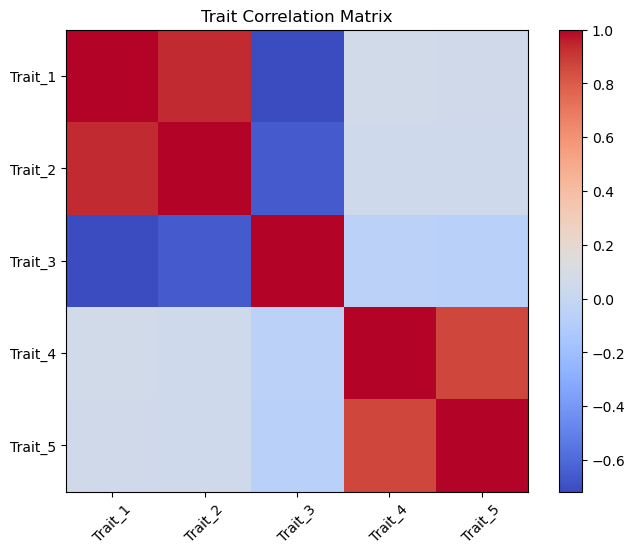

In [2]:
corr = df.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Trait Correlation Matrix")
plt.show()

### Interpretation

We observe:

Trait 1 and Trait 2 are strongly correlated

Trait 3 is negatively correlated

Trait 4 and Trait 5 form another cluster

This hidden structure emerges automatically.

No prior hypothesis was imposed.

### K-Means Clustering

#### Concept

K-means clustering partitions data into clusters based on similarity.

The algorithm:

Chooses cluster centers
    
Assigns samples to nearest center
    
Updates centers iteratively

### K-Means Example

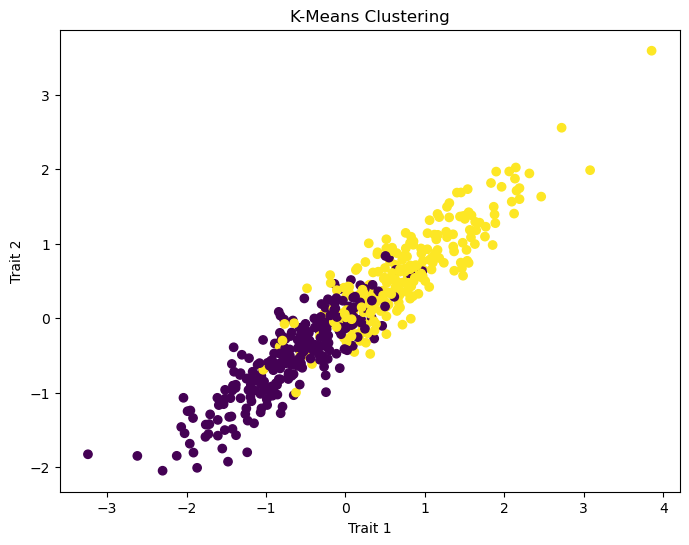

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

plt.figure(figsize=(8,6))

plt.scatter(
    df["Trait_1"],
    df["Trait_2"],
    c=df["Cluster"]
)

plt.xlabel("Trait 1")
plt.ylabel("Trait 2")
plt.title("K-Means Clustering")
plt.show()

### Why Clustering Matters in Genetics

Clustering can help identify:

- disease subtypes
- shared genetic pathways
- pleiotropic mechanisms
- hidden biological modules

#### Applications include:

- psychiatric genetics
- cancer genomics
- transcriptomics
- population genetics

### Principal Component Analysis (PCA)

#### Concept

PCA reduces high-dimensional data into a smaller number of latent variables.

It identifies directions of maximum variance.

Mathematically, PCA relies on:


$$
X = U \Sigma V^T
$$

This is closely related to Singular Value Decomposition(SVD).

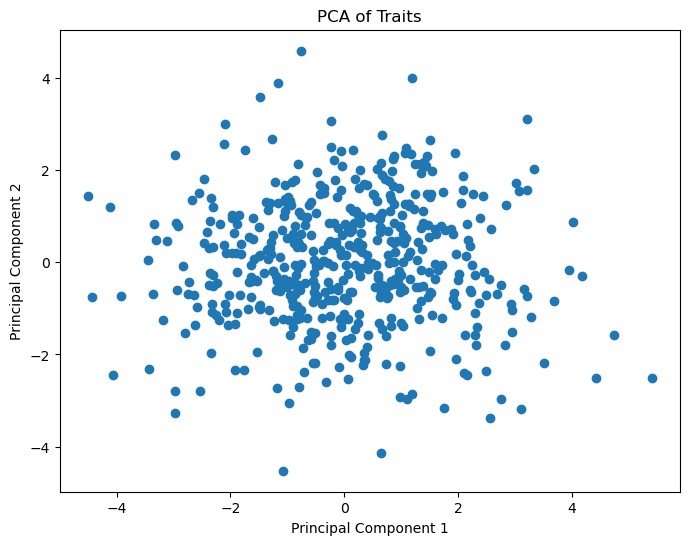

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df.head()

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Traits")
plt.show()

### Interpretation of PCA

#### PCA can reveal:

- latent genetic structure
- ancestry effects
- hidden disease subtypes
- shared molecular mechanisms

It is widely used in:

- GWAS quality control
- population stratification correction
- transcriptomics
- imaging genetics

### Advantages and Limitations  of Hypothesis-Free Methods

| Advantage                  | Explanation               |
| -------------------------- | ------------------------- |
| Discovery-oriented         | Finds unexpected patterns |
| Flexible                   | Minimal assumptions       |
| Scalable                   | Handles many traits       |
| Useful for complex biology | Captures hidden structure |


| Limitation                 | Explanation                          |
| -------------------------- | ------------------------------------ |
| Harder interpretation      | Clusters may lack biological meaning |
| Sensitive to preprocessing | Scaling matters                      |
| Hyperparameter tuning      | Number of clusters matters           |
| Potential overfitting      | Spurious patterns possible           |


## Part 2 — Hypothesis-Driven Analysis

### What is Hypothesis-Driven Analysis?

Hypothesis-driven approaches impose predefined statistical relationships.

Instead of discovering patterns automatically, we test explicit hypotheses.

For example:

>Does polygenic risk score predict depression severity?

or

>Does BMI causally influence diabetes risk?

#### Characteristics

- Strong assumptions
- Confirmatory
- Statistically interpretable
- Often theory-driven
- Suitable for curated trait sets

#### Common methods 

| Method                  | Purpose             |
| ----------------------- | ------------------- |
| Linear Regression       | Association testing |
| Logistic Regression     | Disease prediction  |
| SEM                     | Causal pathways     |
| Mixed Models            | Genetic relatedness |
| Mendelian Randomization | Causal inference    |


#### Linear Regression Example
 
##### Question

 > Can Trait 1 predict Trait 2?

#### Regression Example

In [5]:
import statsmodels.api as sm

X = df["Trait_1"]
y = df["Trait_2"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Trait_2   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     3386.
Date:                Thu, 07 May 2026   Prob (F-statistic):          2.99e-224
Time:                        10:32:04   Log-Likelihood:                -94.422
No. Observations:                 500   AIC:                             192.8
Df Residuals:                     498   BIC:                             201.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0097      0.013      0.741      0.4

#### Interpretation

We now explicitly estimate:

- effect size
- confidence intervals
- statistical significance
- explained variance

This is fundamentally different from exploratory analysis.

### Structural Equation Modeling (SEM)

#### Concept

Structural Equation Modeling combines:

- regression
- covariance analysis
- latent variables

SEM allows researchers to model:

- direct effects
- indirect effects
- latent constructs
- mediation

### Comparison 

| Feature            | Hypothesis-Free   | Hypothesis-Driven |
| ------------------ | ----------------- | ----------------- |
| Goal               | Discover patterns | Test hypotheses   |
| Assumptions        | Minimal           | Strong            |
| Interpretation     | Harder            | Easier            |
| Scalability        | High              | Moderate          |
| Biological insight | Exploratory       | Confirmatory      |


#### When Should You Use Each?

Use Hypothesis-Free Methods When

- exploring new datasets
- analyzing many traits
- discovering subtypes
- searching for hidden patterns


Use Hypothesis-Driven Methods When
- testing biological theories
- validating findings
- estimating effect sizes
- performing causal inference


In Practice: Both Are Often Combined

Modern genomics pipelines frequently use both strategies.

### Typical workflow:

- Exploratory clustering/PCA
- Identify candidate structures
- Validate using regression/SEM
- Replicate findings in external cohorts

This hybrid strategy is extremely powerful.

	

Large-scale genomic studies generate enormous amounts of high-dimensional data, often involving thousands to millions of genetic variants across numerous traits and individuals. Analyzing such datasets presents several important computational and statistical challenges. One major issue is high dimensionality, where the number of variables greatly exceeds the number of samples, making statistical modeling more difficult and increasing the risk of overfitting. Memory usage also becomes a critical concern, especially when handling genotype matrices, covariance structures, and linkage disequilibrium (LD) information for large cohorts.

Another important challenge is covariance estimation across traits. As the number of traits increases, estimating stable and biologically meaningful covariance matrices becomes computationally intensive. In addition, genomic data are strongly influenced by Linkage disequilibrium, where nearby genetic variants are correlated with one another. Ignoring LD structure can lead to biased or misleading results. Population ancestry further complicates analyses because differences in ancestral background may introduce confounding patterns that mimic genuine biological associations. As a result, efficient algorithms, scalable statistical frameworks, and robust correction strategies are essential for modern genomic research.

The key distinction between the two analytical paradigms discussed in this tutorial lies in their objectives and assumptions. Hypothesis-free methods aim to discover hidden patterns, latent structures, and relationships directly from the data with minimal prior assumptions. These approaches are particularly useful for exploratory analyses of complex biological systems involving many correlated traits. In contrast, hypothesis-driven methods are designed to test predefined statistical or biological relationships and are generally more interpretable and theory-oriented.

Both approaches play essential roles in modern Statistical Genetics. Exploratory techniques such as clustering and dimensionality reduction are widely used to uncover hidden subgroups, latent biological pathways, and shared genetic architectures. Meanwhile, explanatory approaches such as regression models and Structural Equation Modeling are commonly applied to validate hypotheses, estimate effect sizes, and investigate causal relationships.

In practice, the strongest biological insights often emerge from combining both strategies. Researchers may first apply exploratory methods to identify hidden patterns in the data and then use hypothesis-driven models to validate and interpret these findings in a biologically meaningful framework.
